# Глава 2


## Задание 2.2

Реализовать `class Sawtooth_wave` - пилообразный сигнал.
Аналитическая запись формы сигнала: $$ x(t) = t - \lfloor t \rfloor \\ x(t) = t \ mod \ 1 $$

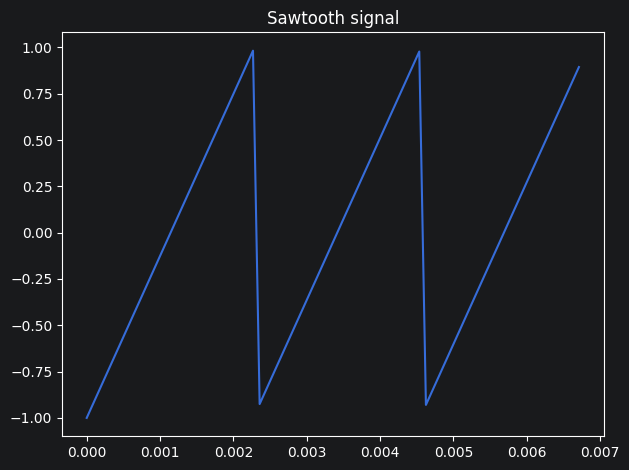

In [1]:
from thinkdsp import Sinusoid, PI2, unbias, normalize, decorate
import numpy as np


class Sawtooth_wave(Sinusoid):
    def evaluate(self, ts):
        cycles = self.freq * ts + self.offset / PI2
        frac, _ = np.modf(cycles)
        ys = normalize(unbias(frac), self.amp)
        return ys


saw_signal = Sawtooth_wave()
saw_signal.plot()
decorate(title="Sawtooth signal")

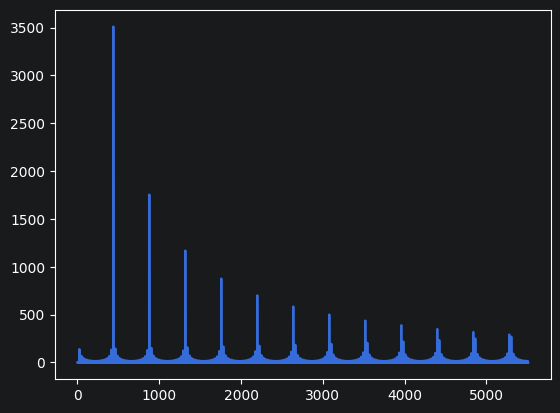

In [2]:
wave = saw_signal.make_wave()
spectrum = wave.make_spectrum()
spectrum.plot()

## Задание 2.3

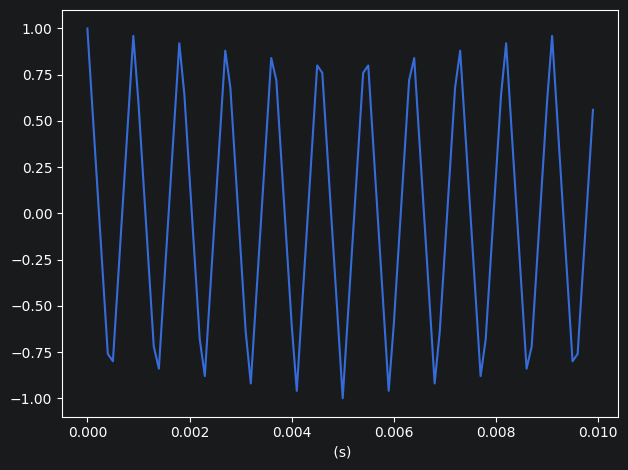

In [12]:
from thinkdsp import TriangleSignal


triangle_signal = TriangleSignal(freq=1100)
wave = triangle_signal.make_wave(framerate=10_000)
spectrum = wave.make_spectrum()
wave.make_audio()

wave_segment = wave.segment(start=0, duration=0.01)
wave_segment.plot()
decorate(xlabel=" (s)")


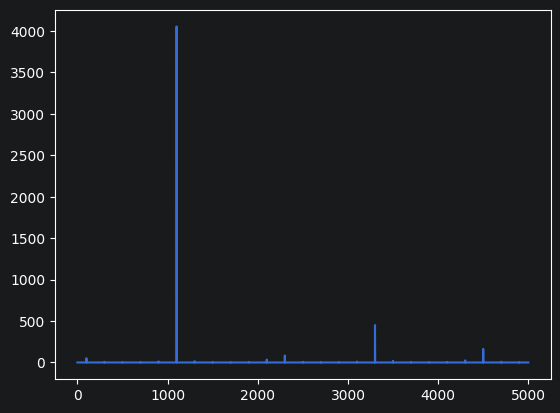

In [11]:
spectrum.plot()
aliased_wave = spectrum.make_wave()
aliased_wave.make_audio()

# Задание 2.4

В упражнении 2.4 исследуется явление утечки спектра (spectral leakage), которое
возникает, когда в анализируемом окне не укладывается целое число периодов сигнала.
Применение оконных функций позволяет значительно уменьшить утечку

Тестируемый сигнал: синусоида 440.7 Гц при длительности 0.5 с

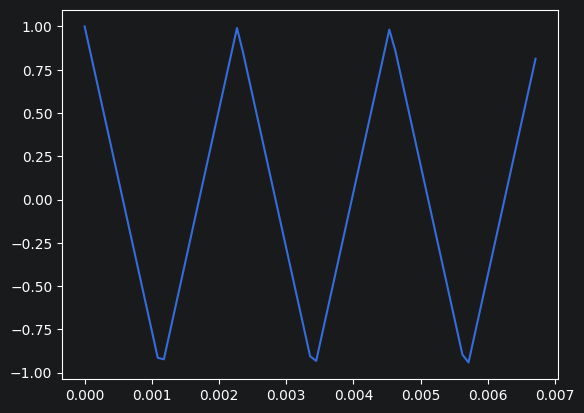

In [13]:
signal = TriangleSignal(freq=440)
wave = signal.make_wave(duration=0.01)
spectrum = wave.make_spectrum()
signal.plot()

In [14]:
spectrum.hs[0]

np.complex128(1.0436096431476471e-14+0j)

In [15]:
z = spectrum.hs[0]
amp  = np.abs(z)
phase = np.angle(z)
print("Amplituda:", amp)
print("Phase:", phase)

Amplituda: 1.0436096431476471e-14
Phase: 0.0


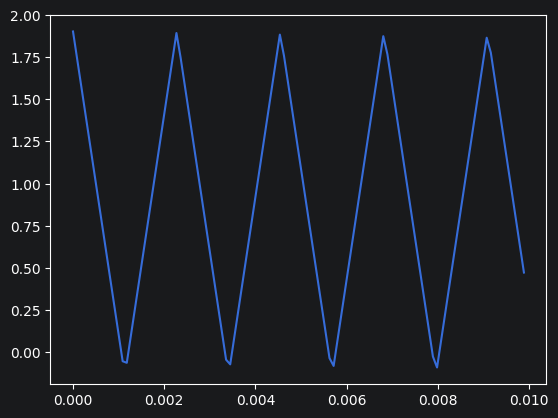

In [16]:
spectrum.hs[0] = 100
new_wave = spectrum.make_wave()
new_wave.plot()

В результате у нас изменилась частота сигнала и амплитуда

## Задание 2.5

Задание 2.5 демонстрирует работу с объектом Spectrum: применение фильтра
нижних частот (ФНЧ) к пилообразному сигналу

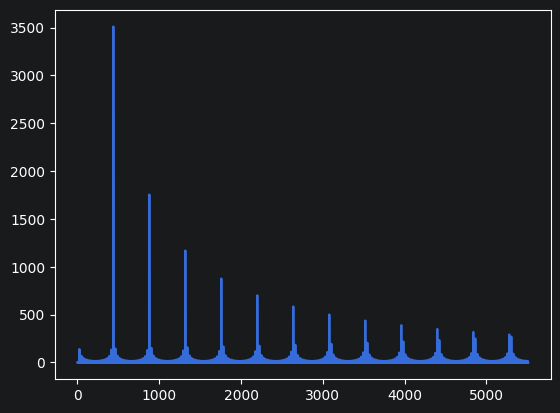

In [17]:
from thinkdsp import Spectrum

def new_spectrum(spectrum: Spectrum):
    spectrum.hs[1:] /= spectrum.fs[1:]
    spectrum.hs[0] = 0

signal = Sawtooth_wave()
wave = signal.make_wave()
spectrum = wave.make_spectrum()
spectrum.plot()
wave.make_audio()

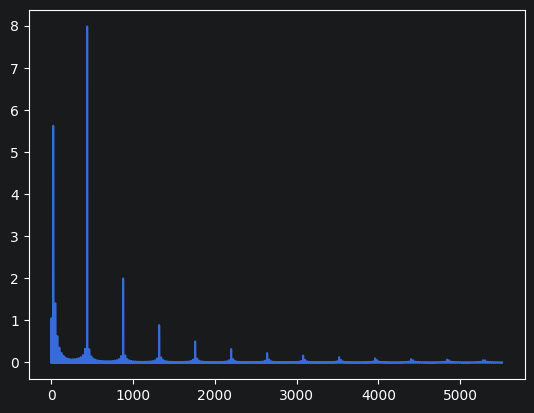

In [19]:
new_spectrum(spectrum)
spectrum.plot()
new_wave = spectrum.make_wave()
new_wave.make_audio()

## Задание 2.6


Исследование броуновского шума

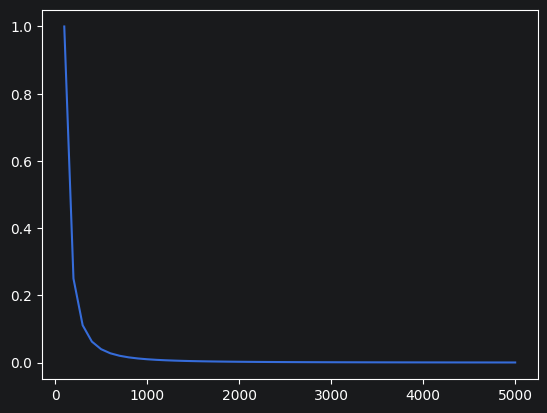

In [20]:
framerate = 10_000
nyquist = framerate / 2
f0 = 100

max_harmonic = int(nyquist // f0)
harmonics = np.arange(1, max_harmonic+1)
fs = harmonics * f0

amplitudes = 1.0 / (fs ** 2)
amplitudes = amplitudes / amplitudes.max()
hs = amplitudes.astype(np.complex128)

spectrum = Spectrum(hs=hs, fs=fs, framerate=framerate)
spectrum.plot()

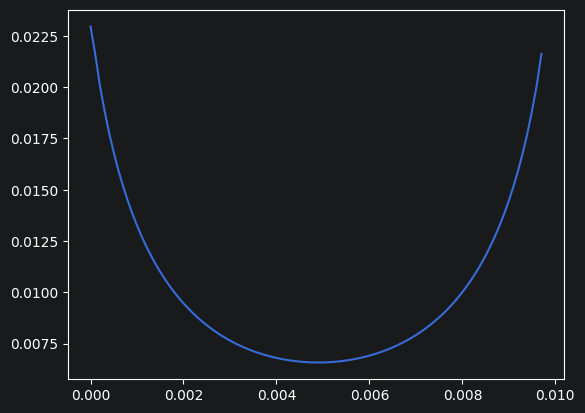

In [21]:
wave = spectrum.make_wave()
wave.plot()